In [1]:
from pathlib import Path
import zipfile
import kagglehub

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import kagglehub

kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [2]:
path = kagglehub.competition_download("11-785-fall-20-homework-2-part-2")

DATASET_ROOT = Path(path)

print("Path to competition files:", DATASET_ROOT)

100%|██████████| 1.35G/1.35G [00:18<00:00, 78.7MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/11-785-fall-20-homework-2-part-2


In [3]:
for zip_path in DATASET_ROOT.rglob("*.zip"):
    extract_to = zip_path.with_suffix("")
    print("Extracting:", zip_path)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_to)

In [4]:
for item in DATASET_ROOT.rglob("*"):
    if item.is_dir():
        print(item)

Streaming output truncated to the last 5000 lines.
/root/.cache/kagglehub/competitions/11-785-fall-20-homework-2-part-2/classification_data/train_data/n004753
/root/.cache/kagglehub/competitions/11-785-fall-20-homework-2-part-2/classification_data/train_data/n009106
/root/.cache/kagglehub/competitions/11-785-fall-20-homework-2-part-2/classification_data/train_data/n008843
/root/.cache/kagglehub/competitions/11-785-fall-20-homework-2-part-2/classification_data/train_data/n007692
/root/.cache/kagglehub/competitions/11-785-fall-20-homework-2-part-2/classification_data/train_data/n008285
/root/.cache/kagglehub/competitions/11-785-fall-20-homework-2-part-2/classification_data/train_data/n003667
/root/.cache/kagglehub/competitions/11-785-fall-20-homework-2-part-2/classification_data/train_data/n005382
/root/.cache/kagglehub/competitions/11-785-fall-20-homework-2-part-2/classification_data/train_data/n001590
/root/.cache/kagglehub/competitions/11-785-fall-20-homework-2-part-2/classification_d

In [75]:

TRAIN_DIR = DATASET_ROOT / "classification_data" / "train_data"
VALID_DIR = DATASET_ROOT / "classification_data" / "val_data"
TEST_DIR  = DATASET_ROOT / "classification_data" / "test_data"

print("Train exists:", TRAIN_DIR.exists(), TRAIN_DIR)
print("Valid exists:", VALID_DIR.exists(), VALID_DIR)
print("Test exists:", TEST_DIR.exists(), TEST_DIR)

Train exists: True /root/.cache/kagglehub/competitions/11-785-fall-20-homework-2-part-2/classification_data/train_data
Valid exists: True /root/.cache/kagglehub/competitions/11-785-fall-20-homework-2-part-2/classification_data/val_data
Test exists: True /root/.cache/kagglehub/competitions/11-785-fall-20-homework-2-part-2/classification_data/test_data


In [54]:
IMAGE_SIZE = (112, 112)
BATCH_SIZE = 64
EPOCHS = 50

train_dataset = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_dataset = keras.utils.image_dataset_from_directory(
    VALID_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

CLASS_NAMES = train_dataset.class_names
NUM_CLASSES = len(CLASS_NAMES)

test_dataset = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


print("Number of identities:", NUM_CLASSES)

Found 380638 files belonging to 4000 classes.
Found 8000 files belonging to 4000 classes.
Found 8000 files belonging to 4000 classes.
Number of identities: 4000


In [55]:
train_dataset = train_dataset.repeat()

train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
valid_dataset = valid_dataset.prefetch(tf.data.AUTOTUNE)

In [56]:
model = keras.Sequential([
    layers.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),

    layers.Rescaling(1./255),

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),

    layers.Conv2D(32, 3, padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(512, 3, padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.GlobalAveragePooling2D(),

    layers.Dense(512, use_bias=False, name="embedding_layer"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.3),


    layers.Dense(NUM_CLASSES, activation="softmax", name="identity_classifier")
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_4 (RandomFlip)      │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 112, 112, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 56, 56, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 14, 14, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 7, 7, 512)      │     1,179,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 7, 7, 512)      │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 3,887,744 (14.83 MB)

 Trainable params: 3,884,736 (14.82 MB)

 Non-trainable params: 3,008 (11.75 KB)

In [57]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0003),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy", keras.metrics.SparseTopKCategoricalAccuracy(k=10)]
)

In [58]:
checkpoint = keras.callbacks.ModelCheckpoint(
    "face_classifier_best.keras",
    monitor="val_loss",
    save_best_only=True
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=0.000001
)

In [59]:
valid_dataset_quick = keras.utils.image_dataset_from_directory(
    VALID_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

valid_dataset_quick = valid_dataset_quick.repeat()
valid_dataset_quick = valid_dataset_quick.prefetch(tf.data.AUTOTUNE)

history = model.fit(
    train_dataset,
    validation_data=valid_dataset_quick,
    epochs=EPOCHS,
    steps_per_epoch=448,
    validation_steps=100,
    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr
    ]
)

Found 8000 files belonging to 4000 classes.
Epoch 1/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - accuracy: 0.0010 - loss: 8.3728 - sparse_top_k_categorical_accuracy: 0.0078 - val_accuracy: 0.0011 - val_loss: 8.3683 - val_sparse_top_k_categorical_accuracy: 0.0063 - learning_rate: 3.0000e-04
Epoch 2/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step - accuracy: 0.0022 - loss: 8.0489 - sparse_top_k_categorical_accuracy: 0.0143 - val_accuracy: 0.0012 - val_loss: 8.1912 - val_sparse_top_k_categorical_accuracy: 0.0122 - learning_rate: 3.0000e-04
Epoch 3/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 36s 81ms/step - accuracy: 0.0029 - loss: 7.7696 - sparse_top_k_categorical_accuracy: 0.0232 - val_accuracy: 0.0020 - val_loss: 7.9032 - val_sparse_top_k_categorical_accuracy: 0.0172 - learning_rate: 3.0000e-04
Epoch 4/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 37s 83ms/step - accuracy: 0.0043 - loss: 7.5364 - sparse_top_k_categorical_accuracy: 0.0332 - val_accuracy: 0.0039 - val_loss: 7.6486 - val_sparse_top_k_categorical_a

In [60]:
results = model.evaluate(test_dataset, return_dict=True)

print("Test loss:", results["loss"])
print("Test accuracy:", results["accuracy"])
print("Test top-k accuracy:", results["sparse_top_k_categorical_accuracy"])

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.3668 - loss: 3.3289 - sparse_top_k_categorical_accuracy: 0.6560
Test loss: 3.3288934230804443
Test accuracy: 0.36675000190734863
Test top-k accuracy: 0.656000018119812


In [77]:
from google.colab import drive
drive.mount("/content/drive")

from tensorflow import keras
import numpy as np

embedding_layer_index = None

for i, layer in enumerate(model.layers):
    if layer.name == "embedding_layer":
        embedding_layer_index = i
        break

print("Embedding layer index:", embedding_layer_index)

for layer in model.layers[embedding_layer_index:embedding_layer_index + 5]:
    print(layer.name)


raw_embedding_output = model.layers[embedding_layer_index + 2].output

x = keras.layers.UnitNormalization(
    axis=1,
    name="l2_normalized_embedding"
)(raw_embedding_output)

embedding_model = keras.Model(
    inputs=model.inputs,
    outputs=x,
    name="face_embedding_model"
)

embedding_model.summary()

embedding_model.save("/content/drive/MyDrive/final_face_embedding_model.keras")
model.save("/content/drive/MyDrive/final_face_classifier_model.keras")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Embedding layer index: 24
embedding_layer
batch_normalization_29
activation_29
dropout_4
identity_classifier


Model: "face_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_4 (RandomFlip)      │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 112, 112, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 56, 56, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 14, 14, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 7, 7, 512)      │     1,179,648 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,835,744 (7.00 MB)

 Trainable params: 1,832,736 (6.99 MB)

 Non-trainable params: 3,008 (11.75 KB)

In [79]:
batch = next(iter(valid_dataset))[0]

embeddings = embedding_model.predict(batch[:8])
norms = np.linalg.norm(embeddings, axis=1)

print(norms)
print("Mean norm:", norms.mean())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 894ms/step
[1.         1.         1.         1.         1.         1.
 1.         0.99999994]
Mean norm: 1.0


In [80]:
from pathlib import Path

embedding_path = Path("/content/drive/MyDrive/final_face_embedding_model.keras")
classifier_path = Path("/content/drive/MyDrive/final_face_classifier_model.keras")

print("Embedding model saved:", embedding_path.exists(), embedding_path)
print("Classifier model saved:", classifier_path.exists(), classifier_path)

Embedding model saved: True /content/drive/MyDrive/final_face_embedding_model.keras
Classifier model saved: True /content/drive/MyDrive/final_face_classifier_model.keras


In [62]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow import keras
from sklearn.metrics import roc_auc_score, roc_curve, auc

PAIRS_FILE = DATASET_ROOT / "verification_pairs_val.txt"
VERIFICATION_DIR = DATASET_ROOT / "verification_data"

print(PAIRS_FILE.exists(), PAIRS_FILE)
print(VERIFICATION_DIR.exists(), VERIFICATION_DIR)

True /root/.cache/kagglehub/competitions/11-785-fall-20-homework-2-part-2/verification_pairs_val.txt
True /root/.cache/kagglehub/competitions/11-785-fall-20-homework-2-part-2/verification_data


In [82]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_curve, roc_auc_score

CUSTOM_MODEL = "CustomClassifierEmbeddingModel"

PAIRS_FILE = DATASET_ROOT / "verification_pairs_val.txt"

pairs_df = pd.read_csv(
    PAIRS_FILE,
    sep=r"\s+",
    header=None,
    names=["img1", "img2", "label"]
)

pairs_df["img1_path"] = pairs_df["img1"].apply(lambda p: DATASET_ROOT / p)
pairs_df["img2_path"] = pairs_df["img2"].apply(lambda p: DATASET_ROOT / p)

print("Pairs:", len(pairs_df))
print("First img1 exists:", pairs_df["img1_path"].iloc[0].exists())
print("First img2 exists:", pairs_df["img2_path"].iloc[0].exists())

labels = pairs_df["label"].astype(int).values

Pairs: 8805
First img1 exists: True
First img2 exists: True


In [83]:
from tensorflow import keras

def load_image(path):
    img = keras.utils.load_img(
        path,
        target_size=IMAGE_SIZE
    )

    img = keras.utils.img_to_array(img)
    return img


def get_embeddings_for_unique_paths(paths, batch_size=BATCH_SIZE):
    paths = list(dict.fromkeys(paths))  # remove duplicates, keep order

    embeddings_dict = {}

    for start in range(0, len(paths), batch_size):
        batch_paths = paths[start:start + batch_size]

        images = []
        for path in batch_paths:
            images.append(load_image(path))

        images = np.array(images)

        embeddings = embedding_model.predict(
            images,
            batch_size=batch_size,
            verbose=0
        )

        for path, embedding in zip(batch_paths, embeddings):
            embeddings_dict[path] = embedding

    return embeddings_dict

In [84]:
all_paths = (
    pairs_df["img1_path"].tolist()
    + pairs_df["img2_path"].tolist()
)

embedding_lookup = get_embeddings_for_unique_paths(all_paths)

left_embeddings = np.array([
    embedding_lookup[path]
    for path in pairs_df["img1_path"]
])

right_embeddings = np.array([
    embedding_lookup[path]
    for path in pairs_df["img2_path"]
])

print("Left embeddings:", left_embeddings.shape)
print("Right embeddings:", right_embeddings.shape)
print("Mean norm:", np.linalg.norm(left_embeddings, axis=1).mean())

Left embeddings: (8805, 512)
Right embeddings: (8805, 512)
Mean norm: 1.0


In [86]:
def l2_normalise(x):
    return x / np.linalg.norm(x, axis=1, keepdims=True)


def calculate_distances(left_embeddings, right_embeddings):
    left_l2 = l2_normalise(left_embeddings)
    right_l2 = l2_normalise(right_embeddings)

    cosine_similarity = np.sum(left_l2 * right_l2, axis=1)
    cosine_similarity = np.clip(cosine_similarity, -1.0, 1.0)

    cosine_distance = 1.0 - cosine_similarity
    euclidean_distance = np.linalg.norm(left_embeddings - right_embeddings, axis=1)
    euclidean_l2_distance = np.linalg.norm(left_l2 - right_l2, axis=1)
    angular_distance = np.arccos(cosine_similarity) / np.pi

    return {
        "cosine": cosine_distance,
        "euclidean": euclidean_distance,
        "euclidean_l2": euclidean_l2_distance,
        "angular": angular_distance
    }


def find_best_threshold(labels, distances):
    # distance: lower = more similar
    # ROC score: higher = more likely same person
    scores = -distances

    fpr, tpr, score_thresholds = roc_curve(labels, scores)

    best_index = np.argmax(tpr - fpr)

    best_distance_threshold = -score_thresholds[best_index]
    auc_score = roc_auc_score(labels, scores)

    return {
        "threshold": float(best_distance_threshold),
        "auc": float(auc_score),
        "tpr": float(tpr[best_index]),
        "fpr": float(fpr[best_index])
    }


distances_by_metric = calculate_distances(
    left_embeddings,
    right_embeddings
)

thresholds = {
    CUSTOM_MODEL: {}
}

for metric_name, distances in distances_by_metric.items():
    result = find_best_threshold(labels, distances)

    thresholds[CUSTOM_MODEL][metric_name] = result["threshold"]

    print(metric_name)
    print("  threshold:", result["threshold"])



cosine
  threshold: 0.4894155263900757
euclidean
  threshold: 0.9893589019775391
euclidean_l2
  threshold: 0.9893589615821838
angular
  threshold: 0.3294290602207184


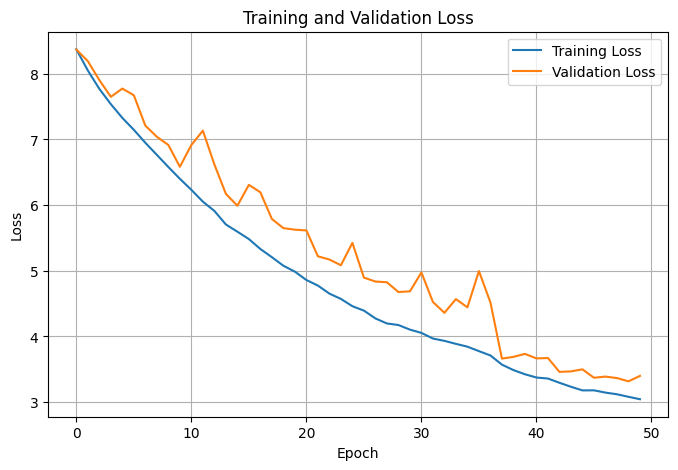

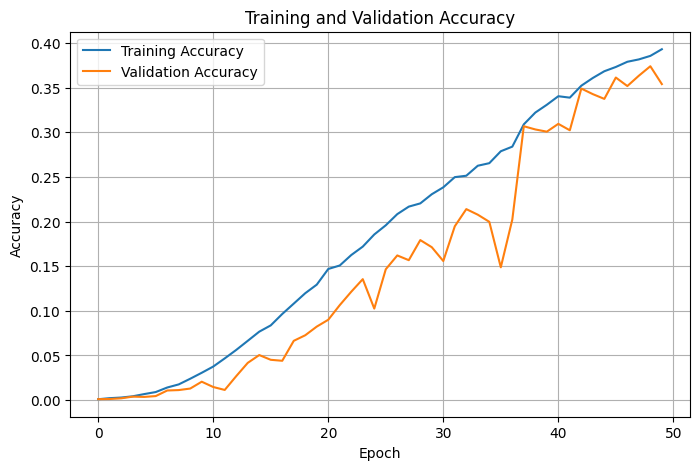

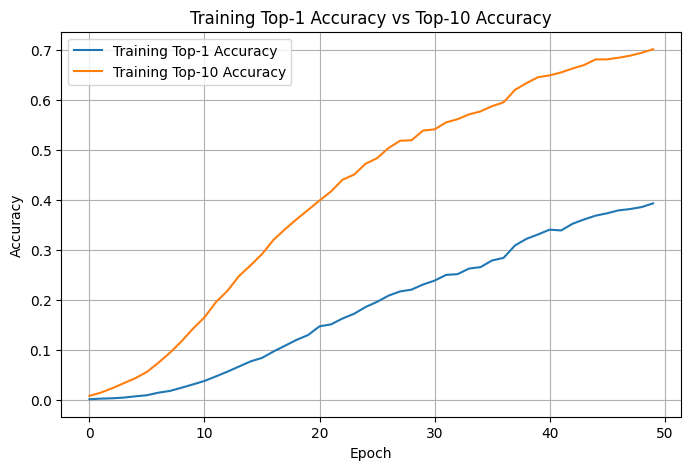

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Top-1 Accuracy")
plt.plot(history.history["sparse_top_k_categorical_accuracy"], label="Training Top-10 Accuracy")

plt.title("Training Top-1 Accuracy vs Top-10 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [88]:
#DEEPFACE INFO

print("Input shape:", embedding_model.input_shape)
print("Output shape:", embedding_model.output_shape)

Input shape: (None, 112, 112, 3)
Output shape: (None, 512)


In [89]:
batch = next(iter(valid_dataset))[0]

embeddings = embedding_model.predict(batch[:8])
norms = np.linalg.norm(embeddings, axis=1)

print(norms)
print("Mean norm:", norms.mean())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
[1.         1.         1.         1.         1.         1.
 1.         0.99999994]
Mean norm: 1.0


In [97]:
#CONFIDENCES


import numpy as np
from sklearn.linear_model import LogisticRegression

def l2_normalise(x):
    return x / np.linalg.norm(x, axis=1, keepdims=True)


def calculate_distances(left_embeddings, right_embeddings):
    left_l2 = l2_normalise(left_embeddings)
    right_l2 = l2_normalise(right_embeddings)

    cosine_similarity = np.sum(left_l2 * right_l2, axis=1)
    cosine_similarity = np.clip(cosine_similarity, -1.0, 1.0)

    return {
        "cosine": 1.0 - cosine_similarity,
        "euclidean": np.linalg.norm(left_embeddings - right_embeddings, axis=1),
        "euclidean_l2": np.linalg.norm(left_l2 - right_l2, axis=1),
        "angular": np.arccos(cosine_similarity) / np.pi
    }


def make_confidence_config(labels, distances):
    labels = np.array(labels).astype(int)
    distances = np.array(distances).astype(float)

    # keeps distance values in a stable 0-ish to 1-ish range
    normalizer = float(np.max(distances))

    if normalizer == 0:
        normalizer = 1.0

    normalised_distances = (distances / normalizer).reshape(-1, 1)

    # learns: distance -> same person probability
    logistic_model = LogisticRegression()
    logistic_model.fit(normalised_distances, labels)

    w = float(logistic_model.coef_[0][0])
    b = float(logistic_model.intercept_[0])

    return {
        "w": w,
        "b": b,
        "normalizer": normalizer,

        "denorm_max_true": 99.0,
        "denorm_min_true": 50.0,

        "denorm_max_false": 49.0,
        "denorm_min_false": 0.0,
    }


distances_by_metric = calculate_distances(
    left_embeddings,
    right_embeddings
)

confidences = {
    CUSTOM_MODEL: {}
}

for metric_name, distances in distances_by_metric.items():
    confidences[CUSTOM_MODEL][metric_name] = make_confidence_config(
        labels,
        distances
    )

print(confidences)


{'CustomClassifierEmbeddingModel': {'cosine': {'w': -8.771574193202731, 'b': 5.000415759855407, 'normalizer': 0.8635047674179077, 'denorm_max_true': 99.0, 'denorm_min_true': 50.0, 'denorm_max_false': 49.0, 'denorm_min_false': 0.0}, 'euclidean': {'w': -12.192513030616036, 'b': 9.148279809318405, 'normalizer': 1.3141573667526245, 'denorm_max_true': 99.0, 'denorm_min_true': 50.0, 'denorm_max_false': 49.0, 'denorm_min_false': 0.0}, 'euclidean_l2': {'w': -12.192511846803123, 'b': 9.14827915775775, 'normalizer': 1.3141573667526245, 'denorm_max_true': 99.0, 'denorm_min_true': 50.0, 'denorm_max_false': 49.0, 'denorm_min_false': 0.0}, 'angular': {'w': -11.727093289922996, 'b': 8.451637254382216, 'normalizer': 0.45641618967056274, 'denorm_max_true': 99.0, 'denorm_min_true': 50.0, 'denorm_max_false': 49.0, 'denorm_min_false': 0.0}}}


In [92]:
import json

print(json.dumps(confidences, indent=4))

{
    "CustomClassifierEmbeddingModel": {
        "cosine": {
            "w": -8.771574193202731,
            "b": 5.000415759855407,
            "normalizer": 0.8635047674179077,
            "denorm_max_true": 99.0,
            "denorm_min_true": 50.0,
            "denorm_max_false": 49.0,
            "denorm_min_false": 0.0
        },
        "euclidean": {
            "w": -12.192513030616036,
            "b": 9.148279809318405,
            "normalizer": 1.3141573667526245,
            "denorm_max_true": 99.0,
            "denorm_min_true": 50.0,
            "denorm_max_false": 49.0,
            "denorm_min_false": 0.0
        },
        "euclidean_l2": {
            "w": -12.192511846803123,
            "b": 9.14827915775775,
            "normalizer": 1.3141573667526245,
            "denorm_max_true": 99.0,
            "denorm_min_true": 50.0,
            "denorm_max_false": 49.0,
            "denorm_min_false": 0.0
        },
        "angular": {
            "w": -11.727093289922